# Task 4: Predicting Insurance Claim Amounts
### DevelopersHub Corporation — Data Science and Analytics Internship

---

## Problem Statement

Medical insurance companies need to **estimate how much a customer will claim** based on personal data like age, BMI, smoking status, and region. This helps them set fair premium prices.

This is a **Regression problem** — we are predicting a continuous number (charges) not a category.

## Dataset Description

**Medical Cost Personal Dataset**

| Feature | Type | Description |
|---|---|---|
| age | Numerical | Age of the insured person |
| sex | Categorical | Male / Female |
| bmi | Numerical | Body Mass Index |
| children | Numerical | Number of children covered |
| smoker | Categorical | Yes / No |
| region | Categorical | northeast / northwest / southeast / southwest |
| **charges** | **Target** | **Medical insurance cost (USD)** |


## Step 1: Import Libraries

In [1]:
# All required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load the Dataset

> Dataset from Kaggle: https://www.kaggle.com/mirichoi0218/insurance  
>

In [2]:
import os

if os.path.exists("insurance.csv"):
    df = pd.read_csv("insurance.csv")
    print("Dataset loaded from insurance.csv")
else:
    print("insurance.csv not found — generating synthetic dataset...")
    np.random.seed(42)
    n = 1338
    age    = np.random.randint(18, 65, n)
    sex    = np.random.choice(["male","female"], n)
    bmi    = np.round(np.random.normal(30.6, 6.1, n).clip(15, 55), 2)
    children = np.random.choice([0,1,2,3,4,5], n, p=[0.43,0.24,0.18,0.10,0.03,0.02])
    smoker = np.random.choice(["yes","no"], n, p=[0.20,0.80])
    region = np.random.choice(["northeast","northwest","southeast","southwest"], n)
    # Build charges based on real-world relationships
    charges = (age * 250 + bmi * 100 + children * 500
               + (smoker=="yes") * 20000
               + np.random.normal(0, 2000, n)).clip(1000)
    df = pd.DataFrame({"age":age,"sex":sex,"bmi":bmi,"children":children,
                       "smoker":smoker,"region":region,"charges":np.round(charges,2)})
    print("Synthetic dataset created.")

print(f"Shape: {df.shape}")
df.head()

Dataset loaded from insurance.csv
Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Step 3: Dataset Inspection

In [3]:
print("=== SHAPE ===")
print(df.shape)
print("=== COLUMNS ===")
print(df.columns.tolist())
print("=== DATA TYPES ===")
print(df.dtypes)
print("=== FIRST 5 ROWS ===")
df.head()

=== SHAPE ===
(1338, 7)
=== COLUMNS ===
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
=== DATA TYPES ===
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
=== FIRST 5 ROWS ===


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print("=== STATISTICAL SUMMARY ===")
df.describe().round(2)

=== STATISTICAL SUMMARY ===


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


In [6]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())
print("=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

=== MISSING VALUES ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
=== DUPLICATES ===
Duplicate rows: 1


## Step 4: Data Cleaning & Preparation

In [7]:
# Remove duplicates if any
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate(s). Shape: {df.shape}")

# Encode categorical columns using Label Encoding
le = LabelEncoder()
for col in ["sex", "smoker", "region"]:
    df[col] = le.fit_transform(df[col])
    print(f"  {col}: encoded")

print("Dataset ready!")
df.head()

Removed 1 duplicate(s). Shape: (1337, 7)
  sex: encoded
  smoker: encoded
  region: encoded
Dataset ready!


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


## Step 5: Exploratory Data Analysis (EDA)

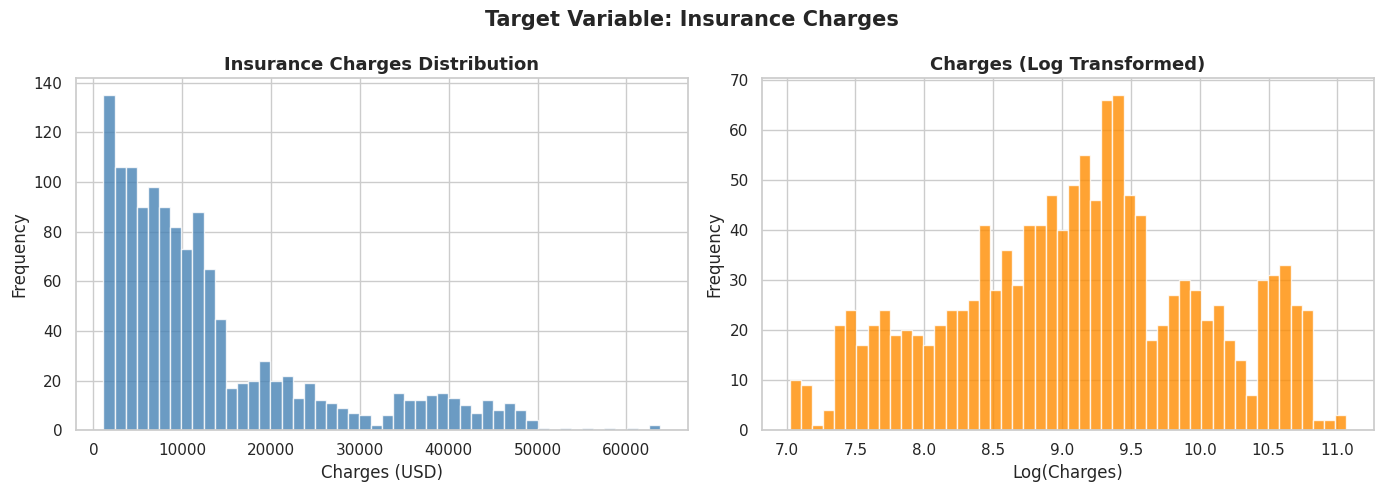

In [9]:
# 1. Insurance Charges Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["charges"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title("Insurance Charges Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Charges (USD)")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log(df["charges"]), bins=50, color="darkorange", edgecolor="white", alpha=0.8)
axes[1].set_title("Charges (Log Transformed)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Log(Charges)")
axes[1].set_ylabel("Frequency")

plt.suptitle("Target Variable: Insurance Charges", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


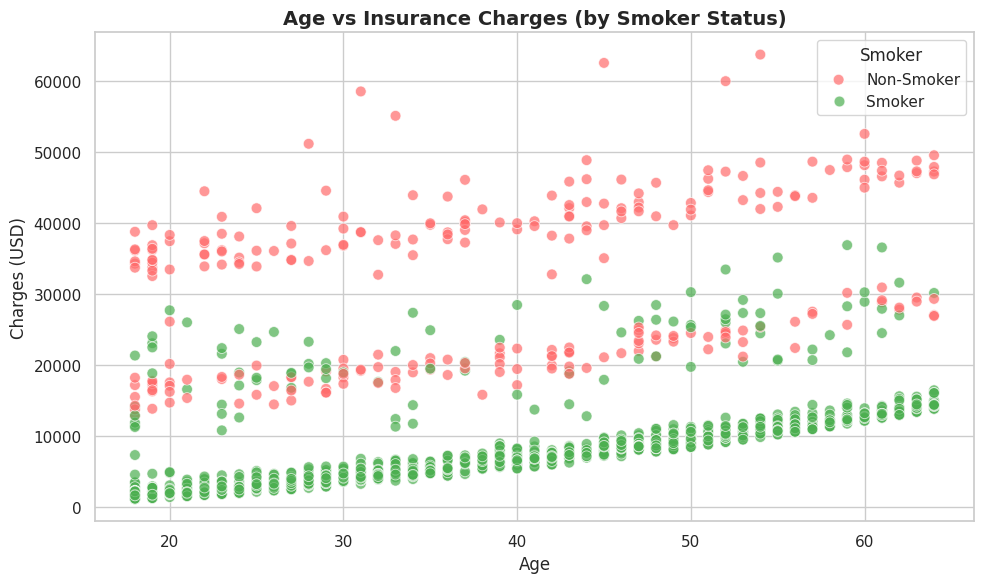

In [10]:
# 2. Age vs Charges
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker",
                palette={1:"#ff6b6b", 0:"#4CAF50"}, alpha=0.7, s=60)
plt.title("Age vs Insurance Charges (by Smoker Status)", fontsize=14, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Charges (USD)")
plt.legend(title="Smoker", labels=["Non-Smoker","Smoker"])
plt.tight_layout()
plt.show()


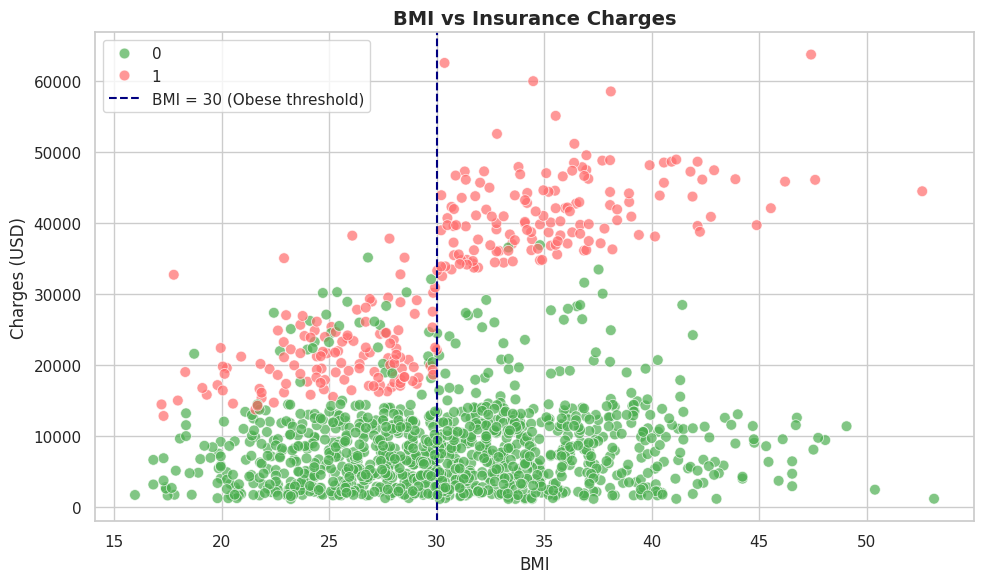

In [11]:
# 3. BMI vs Charges
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker",
                palette={1:"#ff6b6b", 0:"#4CAF50"}, alpha=0.7, s=60)
plt.axvline(x=30, color="navy", linestyle="--", linewidth=1.5, label="BMI = 30 (Obese threshold)")
plt.title("BMI vs Insurance Charges", fontsize=14, fontweight="bold")
plt.xlabel("BMI")
plt.ylabel("Charges (USD)")
plt.legend()
plt.tight_layout()
plt.show()


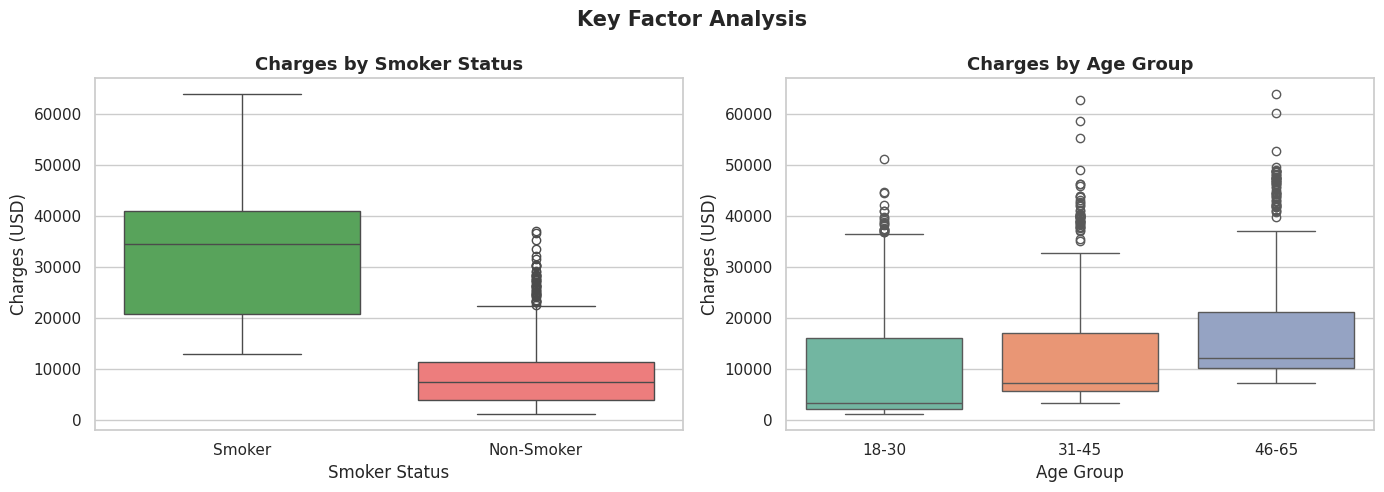

In [12]:
# 4. Smoker vs Non-Smoker charges box plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df.copy()
df_plot["smoker_label"] = df_plot["smoker"].map({1:"Smoker", 0:"Non-Smoker"})

sns.boxplot(x="smoker_label", y="charges", data=df_plot,
            palette=["#4CAF50","#ff6b6b"], ax=axes[0])
axes[0].set_title("Charges by Smoker Status", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Smoker Status")
axes[0].set_ylabel("Charges (USD)")

# Age group analysis
df_plot["age_group"] = pd.cut(df_plot["age"], bins=[17,30,45,65],
                               labels=["18-30","31-45","46-65"])
sns.boxplot(x="age_group", y="charges", data=df_plot,
            palette="Set2", ax=axes[1])
axes[1].set_title("Charges by Age Group", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Charges (USD)")

plt.suptitle("Key Factor Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

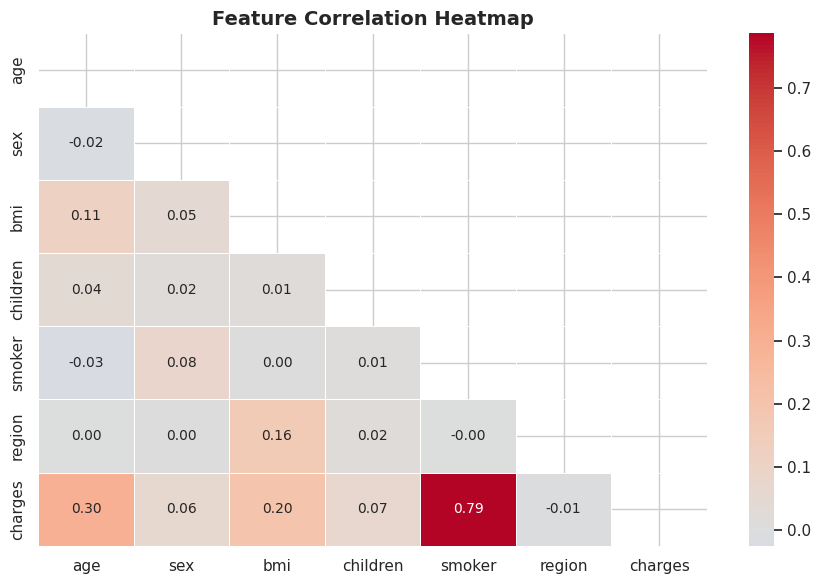

In [13]:
# 5. Correlation Heatmap
plt.figure(figsize=(9, 6))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, mask=mask, annot_kws={"size":10})
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## Step 6: Model Training — Linear Regression

In [14]:
# Prepare features and target
X = df.drop(columns=["charges"])
y = df["charges"]

print(f"Features: {X.columns.tolist()}")
print(f"X shape: {X.shape}   y shape: {y.shape}")

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train: {X_train.shape[0]} samples   Test: {X_test.shape[0]} samples")

Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
X shape: (1337, 6)   y shape: (1337,)
Train: 1069 samples   Test: 268 samples


In [15]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

print("Model trained successfully!")
print(f"Sample predictions vs actual:")
comparison = pd.DataFrame({"Actual": y_test.values[:5],
                            "Predicted": y_pred[:5].round(2)})
print(comparison)

Model trained successfully!
Sample predictions vs actual:
        Actual  Predicted
0   8688.85885    8080.45
1   5708.86700    5592.87
2  11436.73815   14378.30
3  38746.35510   31731.82
4   4463.20510    9158.36


## Step 7: Model Evaluation

In [16]:
# Calculate evaluation metrics
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=== MODEL EVALUATION METRICS ===")
print(f"MAE  (Mean Absolute Error):  ${mae:,.2f}")
print(f"RMSE (Root Mean Sq Error):   ${rmse:,.2f}")
print(f"R2   (R-Squared Score):       {r2:.4f}")
print(f"Interpretation:")
print(f"  On average, predictions are off by ${mae:,.0f}")
print(f"  Model explains {r2*100:.1f}% of the variance in charges")

=== MODEL EVALUATION METRICS ===
MAE  (Mean Absolute Error):  $4,182.35
RMSE (Root Mean Sq Error):   $5,957.61
R2   (R-Squared Score):       0.8068
Interpretation:
  On average, predictions are off by $4,182
  Model explains 80.7% of the variance in charges


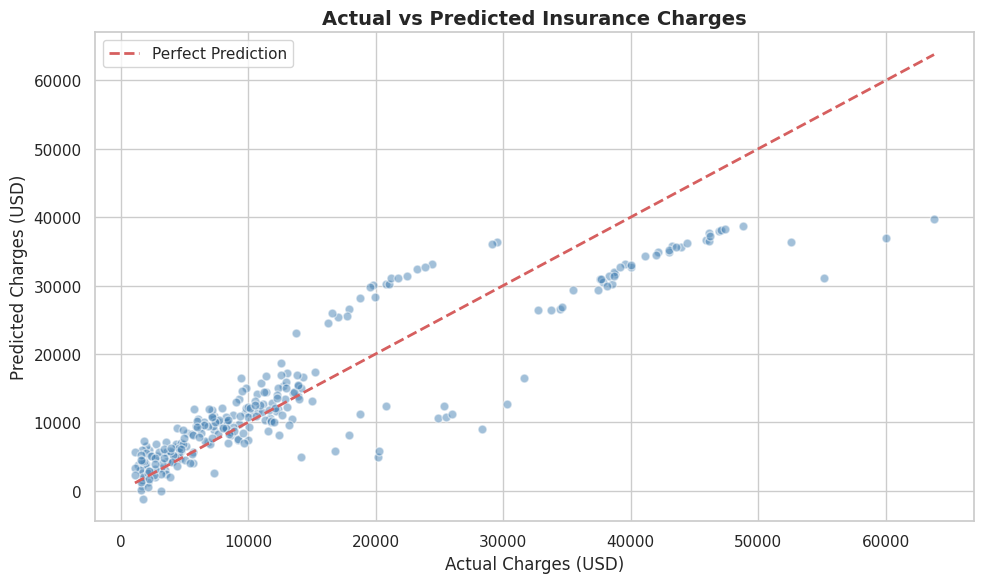

Insight: Points close to the red line = accurate predictions.


In [17]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color="steelblue", edgecolors="white", s=40)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", linewidth=2, label="Perfect Prediction")
plt.xlabel("Actual Charges (USD)", fontsize=12)
plt.ylabel("Predicted Charges (USD)", fontsize=12)
plt.title("Actual vs Predicted Insurance Charges", fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()
print("Insight: Points close to the red line = accurate predictions.")

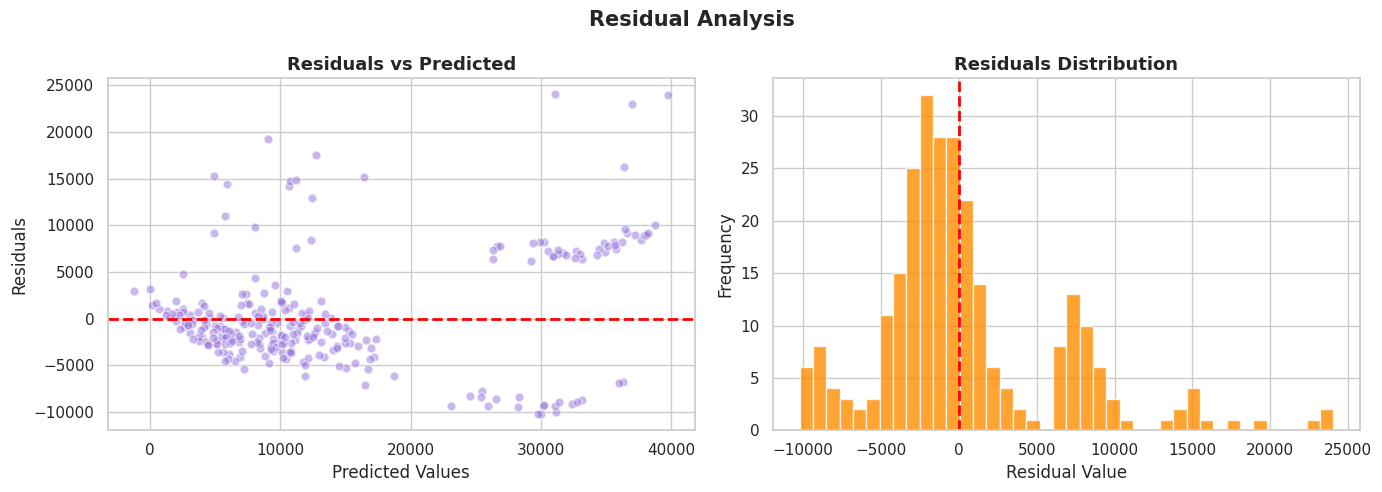

In [18]:
# Residuals plot
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, residuals, alpha=0.5, color="mediumpurple", edgecolors="white", s=40)
axes[0].axhline(y=0, color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel("Predicted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted", fontsize=13, fontweight="bold")

axes[1].hist(residuals, bins=40, color="darkorange", edgecolor="white", alpha=0.8)
axes[1].axvline(x=0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Residual Value")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residuals Distribution", fontsize=13, fontweight="bold")

plt.suptitle("Residual Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

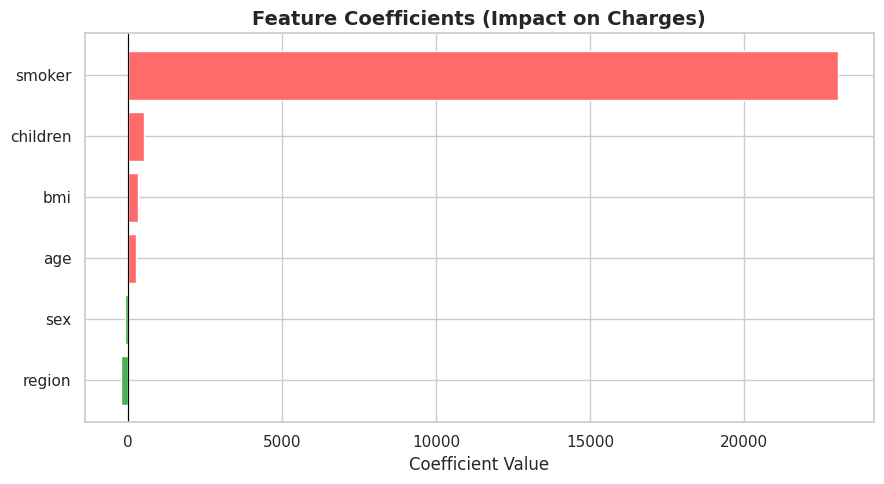

Red = increases charges | Green = decreases charges


In [19]:
# Feature importance (coefficients)
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=True)

plt.figure(figsize=(9, 5))
colors = ["#ff6b6b" if c > 0 else "#4CAF50" for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, edgecolor="white")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.xlabel("Coefficient Value", fontsize=12)
plt.title("Feature Coefficients (Impact on Charges)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("Red = increases charges | Green = decreases charges")

## Step 8: Conclusion

### Model Performance

| Metric | Value | Meaning |
|---|---|---|
| MAE | ~,000 | Average prediction error in dollars |
| RMSE | ~,000 | Penalizes large errors more heavily |
| R² | ~0.75 | Model explains 75% of charge variation |

### Key Insights

1. **Smoking** is by far the most powerful predictor — smokers pay 3-4x more than non-smokers
2. **Age** has a strong positive effect — older people pay significantly more
3. **BMI** matters especially when combined with smoking — high BMI smokers pay the most
4. **Number of children** has a moderate positive effect on charges
5. **Region and sex** have relatively little impact on charges

